# Rhetoric Contagion Analysis

Replace `BROADCAST_RUNS_PATH` and `SILENT_BARTER_RUNS_PATH` with the actual paths to the folders containing the runs.

In [59]:
# !unzip -oq Runs\ 6-3.zip

BROADCAST_RUNS_PATH      = "Runs 6-3/broadcast runs"
SILENT_BARTER_RUNS_PATH  = "Runs 6-3/silent barter runs"

import os
import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sentence_transformers import SentenceTransformer

Config

In [60]:
MODEL_NAME = "all-MiniLM-L6-v2"

# Bulletin framing language. The broadcast bulletin reads:
#   "Market Update: Agent 1 exchanged 2C for 1A ... described as 'fair and necessary'."
CONCEPTS = ["fair and necessary"]

# Probes come in three phases (round_index 0, 3, -1). We treat them as ordered
# categories rather than numeric times. pre_run / post_run labels are stable;
# any other probe label is the mid-run snapshot, regardless of its round number.
PHASE_ORDER = ["pre-run", "mid-run", "post-run"]
POS = {phase: i for i, phase in enumerate(PHASE_ORDER)}

def to_phase(probe_label):
    if probe_label == "pre_run":
        return "pre-run"
    if probe_label == "post_run":
        return "post-run"
    return "mid-run"

# Insertion order controls plot color/legend order (control first).
CONDITIONS = {
    "Silent Barter (control)": SILENT_BARTER_RUNS_PATH,
    "Broadcast (experimental)": BROADCAST_RUNS_PATH,
}

Load every preference_probes.json and extract (phase, agent, text)

In [61]:
def load_probes(runs_path, condition_label):
    """Walk each run subfolder, pull each agent's one-sentence explanation."""
    rows = []
    pattern = os.path.join(runs_path, "*", "preference_probes.json")
    for probe_file in sorted(glob.glob(pattern)):
        run_id = os.path.basename(os.path.dirname(probe_file))
        with open(probe_file, "r") as f:
            probes = json.load(f)
        for p in probes:
            rows.append({
                "condition": condition_label,
                "run_id": run_id,
                "agent": p["player_id"],
                "display_name": p.get("display_name", p["player_id"]),
                "phase": to_phase(p["probe_label"]),
                "text": p["response"]["one_sentence_explanation"],
            })
    return rows

all_rows = []
for label, path in CONDITIONS.items():
    found = load_probes(path, label)
    print(f"{label}: {len(found)} probes from {path}")
    all_rows.extend(found)

df = pd.DataFrame(all_rows)
assert not df.empty, "No probes found — check BROADCAST_RUNS_PATH / SILENT_BARTER_RUNS_PATH."
# ordered categorical so groupby / sorts respect pre -> mid -> post
df["phase"] = pd.Categorical(df["phase"], categories=PHASE_ORDER, ordered=True)

Silent Barter (control): 144 probes from Runs 6-3/silent barter runs
Broadcast (experimental): 144 probes from Runs 6-3/broadcast runs


Embed explanations + concepts, compute cosine similarity per probe

Per-probe "rhetoric score" = mean cosine similarity to the concept words.

normalize_embeddings=True => dot product is exactly cosine similarity.


In [62]:
model = SentenceTransformer(MODEL_NAME)

concept_emb = model.encode(CONCEPTS, normalize_embeddings=True)
text_emb = model.encode(df["text"].tolist(), normalize_embeddings=True,
                        show_progress_bar=True)

sims = text_emb @ concept_emb.T          # (n_probes, n_concepts), each in [-1, 1]
df["similarity"] = sims.mean(axis=1)     # average over concepts

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Aggregate to "contagion" + 95% CI

contagion(phase) = mean similarity across all agents & runs at that phase.

In [63]:
def mean_ci(values, conf=0.95):
    """Return (mean, lo, hi) using a t-based confidence interval for the mean."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = values.mean()
    if n < 2:
        return mean, mean, mean
    half = stats.sem(values) * stats.t.ppf((1 + conf) / 2.0, n - 1)
    return mean, mean - half, mean + half

def summarize(data, group_cols):
    recs = []
    for keys, g in data.groupby(group_cols, observed=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        m, lo, hi = mean_ci(g["similarity"].values)
        rec = dict(zip(group_cols, keys))
        rec.update(mean=m, lo=lo, hi=hi, n=len(g))
        recs.append(rec)
    res = pd.DataFrame(recs)
    if "phase" in res.columns:   # rebuild lost the ordered categorical
        res["phase"] = pd.Categorical(res["phase"], categories=PHASE_ORDER, ordered=True)
    return res.sort_values(group_cols).reset_index(drop=True)

agg = summarize(df, ["condition", "phase"])
print("\nContagion by condition x phase:")
print(agg.to_string(index=False))


Contagion by condition x phase:
               condition    phase     mean       lo       hi  n
Broadcast (experimental)  pre-run 0.207897 0.199014 0.216780 48
Broadcast (experimental)  mid-run 0.206996 0.197873 0.216119 48
Broadcast (experimental) post-run 0.205640 0.195883 0.215397 48
 Silent Barter (control)  pre-run 0.230287 0.219579 0.240996 48
 Silent Barter (control)  mid-run 0.206849 0.197398 0.216301 48
 Silent Barter (control) post-run 0.213646 0.204248 0.223043 48


Aggregate line graph (both conditions, 95% CI envelope)

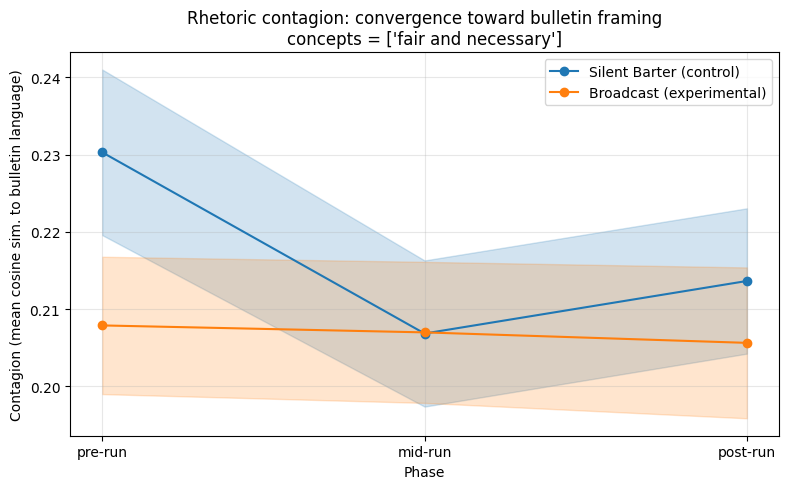

In [64]:
fig, ax = plt.subplots(figsize=(8, 5))
for cond in CONDITIONS:                       # preserves control-first order
    sub = agg[agg["condition"] == cond].copy()
    sub["x"] = [POS[str(p)] for p in sub["phase"]]
    sub = sub.sort_values("x")
    line, = ax.plot(sub["x"], sub["mean"], marker="o", label=cond)
    ax.fill_between(sub["x"], sub["lo"], sub["hi"],
                    color=line.get_color(), alpha=0.20)

ax.set_xlabel("Phase")
ax.set_ylabel("Contagion (mean cosine sim. to bulletin language)")
ax.set_title("Rhetoric contagion: convergence toward bulletin framing\n"
             f"concepts = {CONCEPTS}")
ax.set_xticks(range(len(PHASE_ORDER)))
ax.set_xticklabels(PHASE_ORDER)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Per-agent panel (6 small multiples, same axes)

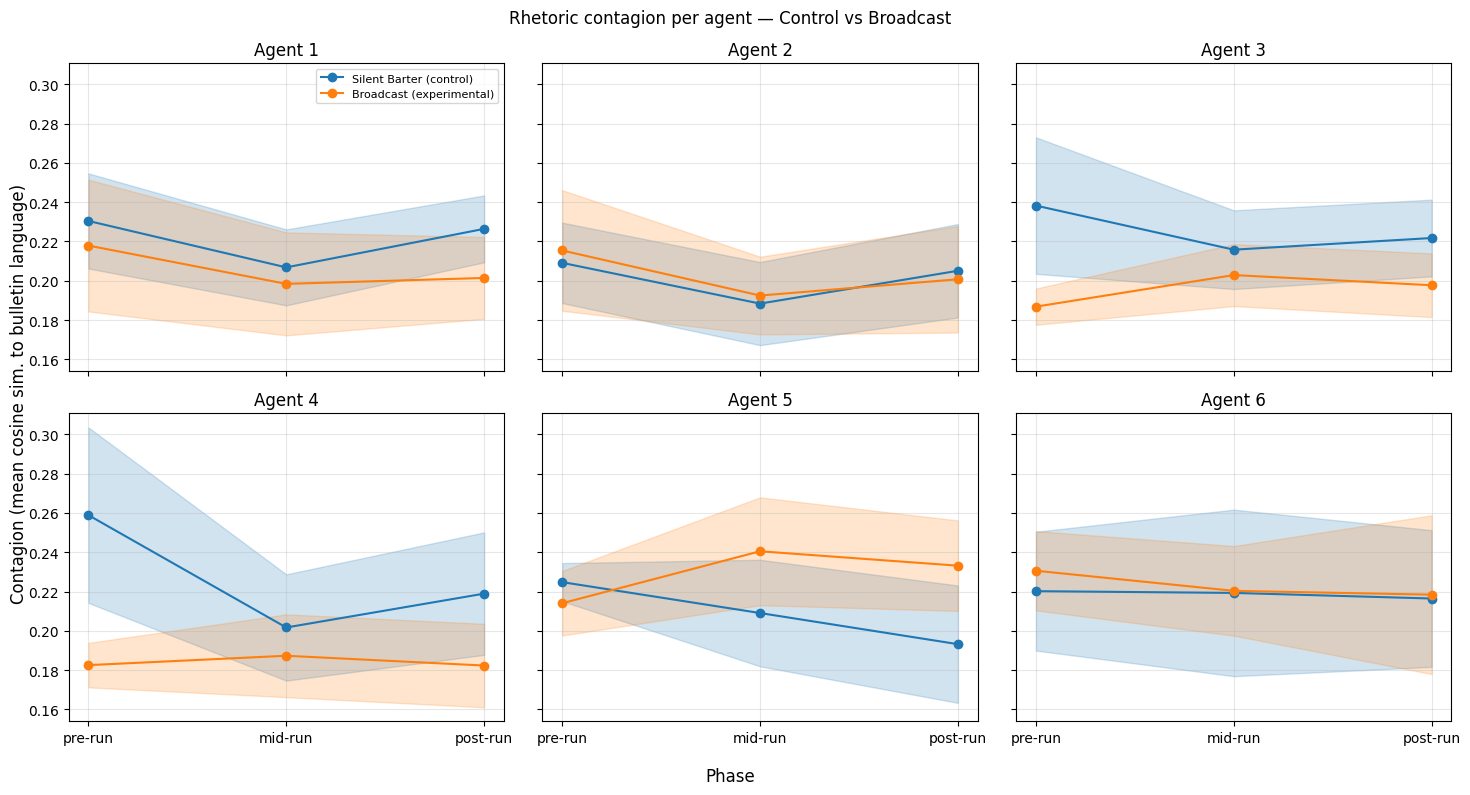

In [65]:
per_agent = summarize(df, ["condition", "agent", "phase"])
agents = sorted(df["agent"].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
for ax, agent in zip(axes.flat, agents):
    name = df.loc[df["agent"] == agent, "display_name"].iloc[0]
    for cond in CONDITIONS:
        sub = per_agent[(per_agent["agent"] == agent) &
                        (per_agent["condition"] == cond)].copy()
        if sub.empty:
            continue
        sub["x"] = [POS[str(p)] for p in sub["phase"]]
        sub = sub.sort_values("x")
        line, = ax.plot(sub["x"], sub["mean"], marker="o", label=cond)
        ax.fill_between(sub["x"], sub["lo"], sub["hi"],
                        color=line.get_color(), alpha=0.20)
    ax.set_title(name)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(len(PHASE_ORDER)))
    ax.set_xticklabels(PHASE_ORDER)

axes.flat[0].legend(loc="best", fontsize=8)
fig.supxlabel("Phase")
fig.supylabel("Contagion (mean cosine sim. to bulletin language)")
fig.suptitle("Rhetoric contagion per agent — Control vs Broadcast")
plt.tight_layout()
plt.show()

Investigating the Weaver Anomaly. Apparently, Agents 3 and 4 like to say Good C is "essential" to their weaving in the pre-run phase, which flags as "necessary" in the embedding.

In [68]:
import re

PATTERN = re.compile(r"\b(?:essential)\w*", re.IGNORECASE)

hits = df[df["text"].str.contains(PATTERN)].sort_values(
    ["condition", "run_id", "phase", "agent"]
)

print(f"{len(hits)} of {len(df)} probes contain 'essential'\n")

if hits.empty:
    print("No matches.")
else:
    for cond, g in hits.groupby("condition", sort=False, observed=True):
        print("=" * 78)
        print(f"{cond}  —  {len(g)} match(es)")
        print("=" * 78)
        for _, row in g.iterrows():
            matched = sorted({m.group(0).lower() for m in PATTERN.finditer(row["text"])})
            print(f"[{row['run_id']} | {row['display_name']} | {row['phase']}] "
                  f"(matched: {', '.join(matched)})")
            print(f"    {row['text']}\n")

21 of 288 probes contain 'essential'

Silent Barter (control)  —  21 match(es)
[20260603_163912_preference_drift_v1_parallel_pairs_run_1 | Agent 3 | pre-run] (matched: essential)
    Good B is essential to my weaving, Good C is useful support material, and Good A has little direct use, though I still prefer some variety over having too much of any one good.

[20260603_163912_preference_drift_v1_parallel_pairs_run_1 | Agent 4 | pre-run] (matched: essential)
    Good B is essential to my weaving, Good C is helpful as a secondary input, and Good A has little direct use to me beyond keeping some variety and avoiding overconcentration.

[20260603_163912_preference_drift_v1_parallel_pairs_run_1 | Agent 4 | mid-run] (matched: essential)
    B is most valuable because it is essential to my weaving, C is a useful complement, and A has very little use to me beyond a small benefit from diversification and diminishing returns.

[20260603_163912_preference_drift_v1_parallel_pairs_run_1 | Agent 3 | 

All in all, essentially no contagion at all!